# Plate Characters and Numbers Detection Notebook

## Installs and Imports

In [ ]:
!pip install roboflow
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install Ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 143.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.9 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
from ctypes import BigEndianStructure
from ultralytics import YOLO
from IPython.display import Image as IPyImage, display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import os
from ipywidgets import HBox, Image as WImage
import base64
from collections import Counter
from collections import defaultdict
from PIL import Image
import yaml
import plotly.graph_objects as go
import cv2
from io import BytesIO
from tqdm import tqdm
import albumentations as A
import shutil

## Data Loading

In [ ]:
rf = Roboflow(api_key="YBaBoieNSNnA7fkaAghG")
project = rf.workspace("fbi-senstive-information").project("egypt-car-plates")
version = project.version(3)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Egypt-car-plates-3 in yolov12:: 100%|██████████| 5804/5804 [00:00<00:00, 6913.10it/s]


In [ ]:
rf = Roboflow(api_key="YBaBoieNSNnA7fkaAghG")
project = rf.workspace("alyalsayed-vyx6g").project("egyptian-car-plates")
version = project.version(13)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to egyptian-car-plates-13 in yolov12:: 100%|██████████| 12676/12676 [00:01<00:00, 10664.90it/s]


In [ ]:
merged_dataset_base_path = "/content/merged_car_plates"

os.makedirs(merged_dataset_base_path, exist_ok=True)

splits = ["train", "valid", "test"]

for split in splits:
    split_path = os.path.join(merged_dataset_base_path, split)
    os.makedirs(split_path, exist_ok=True)
    os.makedirs(os.path.join(split_path, "images"), exist_ok=True)
    os.makedirs(os.path.join(split_path, "labels"), exist_ok=True)

print(f"Created merged dataset directory structure at: {merged_dataset_base_path}")

Created merged dataset directory structure at: /content/merged_car_plates


## Preprocessing

In [ ]:
universal_label_map = {
    "0": "٠", "1": "١", "2": "٢", "3": "٣", "4": "٤",
    "5": "٥", "6": "٦", "7": "٧", "8": "٨", "9": "٩",
    "a": "أ", "b": "ب", "d": "د", "f": "ف", "g": "ج", "h": "ه",
    "k": "ك", "l": "ل", "m": "م", "n": "ن", "q": "ق",
    "r": "ر", "s": "س", "t": "ط", "w": "و", "y": "ى",
    "baa": "ب", "taa": "ت", "Taa": "ط", "ain": "ع", "daal": "د", "faa": "ف", "ghayn": "غ", "haa": "ه",
    "jeem": "ج", "kaaf": "ك", "laam": "ل", "qaaf": "ق", "raa": "ر", "waw": "و",
    "mem": "م", "meem": "م", "noon": "ن", "non": "ن", "sad": "ص", "saad": "ص", "seen": "س", "sen": "س", "en": "ع",
    "7aa": "ح", "thaa": "ث", "khaa": "خ", "zaal": "ذ",
    "zay": "ز", "sheen": "ش", "daad": "ض", "Thaa": "ظ", "ghain": "غ",
    "yaa": "ى", "alif": "أ"
}

unified_arabic_names = sorted(list(set(universal_label_map.values())))

unified_arabic_to_id = {name: i for i, name in enumerate(unified_arabic_names)}

print(f"Universal Label Map created with {len(universal_label_map)} entries.")
print(f"Unified Arabic Names: {unified_arabic_names}")
print(f"Unified Arabic To ID Mapping: {unified_arabic_to_id}")

Universal Label Map created with 60 entries.
Unified Arabic Names: ['أ', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', '٠', '١', '٢', '٣', '٤', '٥', '٦', '٧', '٨', '٩']
Unified Arabic To ID Mapping: {'أ': 0, 'ب': 1, 'ت': 2, 'ث': 3, 'ج': 4, 'ح': 5, 'خ': 6, 'د': 7, 'ذ': 8, 'ر': 9, 'ز': 10, 'س': 11, 'ش': 12, 'ص': 13, 'ض': 14, 'ط': 15, 'ظ': 16, 'ع': 17, 'غ': 18, 'ف': 19, 'ق': 20, 'ك': 21, 'ل': 22, 'م': 23, 'ن': 24, 'ه': 25, 'و': 26, 'ى': 27, '٠': 28, '١': 29, '٢': 30, '٣': 31, '٤': 32, '٥': 33, '٦': 34, '٧': 35, '٨': 36, '٩': 37}


In [ ]:
original_egypt_car_plates_3_data_yaml = "/content/Egypt-car-plates-3/data.yaml"

with open(original_egypt_car_plates_3_data_yaml, "r", encoding="utf-8") as f:
    egyptian_car_plates_13_data = yaml.safe_load(f)

original_egypt_car_plates_3_names = egyptian_car_plates_13_data["names"]
original_egypt_car_plates_3_id_to_name = {i: name for i, name in enumerate(original_egypt_car_plates_3_names)}

print(f"Original class names for Egypt-car-plates-3: {original_egypt_car_plates_3_names}")

Original class names for Egypt-car-plates-3: ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'car plate', 'd', 'en', 'f', 'g', 'h', 'k', 'l', 'mem', 'non', 'q', 'r', 'sad', 'sen', 't', 'w', 'y']


In [ ]:
egypt_car_plates_3_base_path = "/content/Egypt-car-plates-3"

def process_and_copy_split(
    src_base_path,
    dest_base_path,
    split,
    original_id_to_name_map,
    universal_char_map,
    unified_char_to_id_map,
    exclude_classes=None
):
    src_images_dir = os.path.join(src_base_path, split, "images")
    src_labels_dir = os.path.join(src_base_path, split, "labels")
    dest_images_dir = os.path.join(dest_base_path, split, "images")
    dest_labels_dir = os.path.join(dest_base_path, split, "labels")

    print(f"Processing {split} split from {src_base_path}...")

    for label_file in os.listdir(src_labels_dir):
        if not label_file.endswith(".txt"):
            continue

        src_label_path = os.path.join(src_labels_dir, label_file)
        dest_label_path = os.path.join(dest_labels_dir, label_file)

        new_label_lines = []
        with open(src_label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            original_class_id = int(parts[0])
            original_class_name = original_id_to_name_map.get(original_class_id)

            if exclude_classes and original_class_name in exclude_classes:
                continue

            unified_arabic_char = universal_char_map.get(original_class_name)
            if unified_arabic_char is None:
                print(f"Warning: '{original_class_name}' not found in universal_char_map. Skipping line in {label_file}")
                continue

            new_class_id = unified_char_to_id_map.get(unified_arabic_char)
            if new_class_id is None:
                print(f"Warning: '{unified_arabic_char}' not found in unified_char_to_id_map. Skipping line in {label_file}")
                continue

            new_line = f"{new_class_id} {' '.join(parts[1:])}"
            new_label_lines.append(new_line)

        if new_label_lines:
            with open(dest_label_path, "w", encoding="utf-8") as f:
                f.write("\n".join(new_label_lines))

            image_filename_base = os.path.splitext(label_file)[0]
            img_extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff']
            src_image_path = None
            for ext in img_extensions:
                potential_path = os.path.join(src_images_dir, image_filename_base + ext)
                if os.path.exists(potential_path):
                    src_image_path = potential_path
                    break

            if src_image_path:
                shutil.copy(src_image_path, dest_images_dir)
            else:
                print(f"Warning: Image not found for label {label_file}")
        else:
            pass

    print(f"Finished processing {split} split.")


for split_name in splits:
    process_and_copy_split(
        src_base_path=egypt_car_plates_3_base_path,
        dest_base_path=merged_dataset_base_path,
        split=split_name,
        original_id_to_name_map=original_egypt_car_plates_3_id_to_name,
        universal_char_map=universal_label_map,
        unified_char_to_id_map=unified_arabic_to_id,
        exclude_classes=["car plate"]
    )

print("Egypt-car-plates-3 dataset processed and merged successfully.")

Processing train split from /content/Egypt-car-plates-3...
Finished processing train split.
Processing valid split from /content/Egypt-car-plates-3...
Finished processing valid split.
Processing test split from /content/Egypt-car-plates-3...
Finished processing test split.
Egypt-car-plates-3 dataset processed and merged successfully.


In [ ]:
egyptian_car_plates_13_data_yaml = "/content/egyptian-car-plates-13/data.yaml"

with open(egyptian_car_plates_13_data_yaml, "r", encoding="utf-8") as f:
    egyptian_car_plates_13_data = yaml.safe_load(f)

original_egyptian_car_plates_13_names = egyptian_car_plates_13_data["names"]
original_egyptian_car_plates_13_id_to_name = {i: name for i, name in enumerate(original_egyptian_car_plates_13_names)}

print(f"Original class names for egyptian-car-plates-13: {original_egyptian_car_plates_13_names}")

Original class names for egyptian-car-plates-13: ['0', '1', '2', '3', '4', '5', '6', '7', '7aa', '8', '9', 'Taa', 'Thaa', 'ain', 'alif', 'baa', 'daad', 'daal', 'faa', 'ghayn', 'haa', 'jeem', 'kaaf', 'khaa', 'laam', 'meem', 'noon', 'qaaf', 'raa', 'saad', 'seen', 'sheen', 'taa', 'thaa', 'waw', 'yaa', 'zaal', 'zay']


In [ ]:
egyptian_car_plates_13_base_path = "/content/egyptian-car-plates-13"

for split_name in splits:
    process_and_copy_split(
        src_base_path=egyptian_car_plates_13_base_path,
        dest_base_path=merged_dataset_base_path,
        split=split_name,
        original_id_to_name_map=original_egyptian_car_plates_13_id_to_name,
        universal_char_map=universal_label_map,
        unified_char_to_id_map=unified_arabic_to_id,
        exclude_classes=["car plate"]
    )

print("egyptian-car-plates-13 dataset processed and merged successfully.")

Processing train split from /content/egyptian-car-plates-13...
Finished processing train split.
Processing valid split from /content/egyptian-car-plates-13...
Finished processing valid split.
Processing test split from /content/egyptian-car-plates-13...
Finished processing test split.
egyptian-car-plates-13 dataset processed and merged successfully.


In [ ]:
merged_data_yaml_path = os.path.join(merged_dataset_base_path, "data.yaml")

merged_data_yaml_content = {
    "path": "../merged_car_plates",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(unified_arabic_names),
    "names": unified_arabic_names
}

with open(merged_data_yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(merged_data_yaml_content, f, allow_unicode=True)

print(f"Merged data.yaml created at: {merged_data_yaml_path}")
print("Content of merged data.yaml:")
print(yaml.dump(merged_data_yaml_content, allow_unicode=True))

Merged data.yaml created at: /content/merged_car_plates/data.yaml
Content of merged data.yaml:
names:
- أ
- ب
- ت
- ث
- ج
- ح
- خ
- د
- ذ
- ر
- ز
- س
- ش
- ص
- ض
- ط
- ظ
- ع
- غ
- ف
- ق
- ك
- ل
- م
- ن
- ه
- و
- ى
- ٠
- ١
- ٢
- ٣
- ٤
- ٥
- ٦
- ٧
- ٨
- ٩
nc: 38
path: ../merged_car_plates
test: test/images
train: train/images
val: valid/images



In [ ]:
labels_dir = f"{merged_dataset_base_path}/train/labels"

with open(merged_data_yaml_path) as f:
    data = yaml.safe_load(f)
names = data["names"]

counts = Counter()
for file in os.listdir(labels_dir):
    with open(os.path.join(labels_dir, file)) as f:
        for line in f:
            cls_id = int(line.split()[0])
            counts[cls_id] += 1

for cls_id, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{names[cls_id]:<20} : {count}")

١                    : 3369
٦                    : 2908
٥                    : 2533
٤                    : 2470
٧                    : 2468
٩                    : 2331
٣                    : 2288
٢                    : 2213
٨                    : 1992
أ                    : 1336
م                    : 1253
ر                    : 1039
س                    : 1028
و                    : 979
د                    : 975
ن                    : 925
ق                    : 912
ع                    : 900
ج                    : 871
ه                    : 870
٠                    : 862
ف                    : 845
ب                    : 843
ل                    : 823
ى                    : 800
ط                    : 791
ص                    : 683
ك                    : 380
ث                    : 324
ش                    : 318
غ                    : 318
ظ                    : 310
خ                    : 302
ت                    : 286
ز                    : 280
ذ                    : 264
ح              

In [ ]:
valid_labels_dir = f"{merged_dataset_base_path}/valid/labels"
test_labels_dir = f"{merged_dataset_base_path}/test/labels"

def check_empty_labels(path):
    empty_files = []
    for file in os.listdir(path):
        file_path = os.path.join(path, file)
        if os.path.isfile(file_path) and os.path.getsize(file_path) == 0:
            empty_files.append(file_path)
    return empty_files

empty_train = check_empty_labels(labels_dir)
empty_valid = check_empty_labels(valid_labels_dir)
empty_test = check_empty_labels(test_labels_dir)

print("Empty train labels:", empty_train)
print("Empty valid labels:", empty_valid)
print("Empty test labels:", empty_test)

Empty train labels: []
Empty valid labels: []
Empty test labels: []


## Model Training

In [ ]:
model = YOLO("yolo12n.pt")
train_results = model.train(
    data=merged_data_yaml_path,
    epochs=100,
    imgsz=640,
    batch=64,
    patience=7,
    lr0=0.001,
    optimizer="AdamW",
)

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_car_plates/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=7, perspective=0.0, plots=Tru

## Evaluation

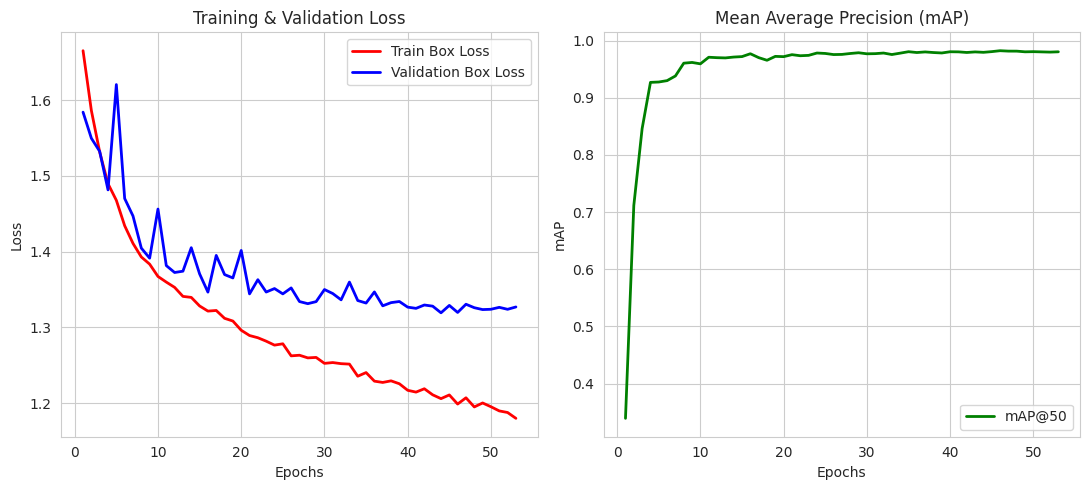

In [ ]:
df = pd.read_csv('/content/runs/detect/train/results.csv')

map_column = "metrics/mAP50(B)"
loss_column_train = "train/box_loss"
loss_column_val = "val/box_loss"

plt.figure(figsize=(11,5))

sns.set_style("whitegrid")

plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df[loss_column_train], label="Train Box Loss", color="red", linewidth=2)
plt.plot(df["epoch"], df[loss_column_val], label="Validation Box Loss", color="blue", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df[map_column], label="mAP@50", color="green", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.title("Mean Average Precision (mAP)")
plt.legend()

plt.tight_layout()

plt.show()

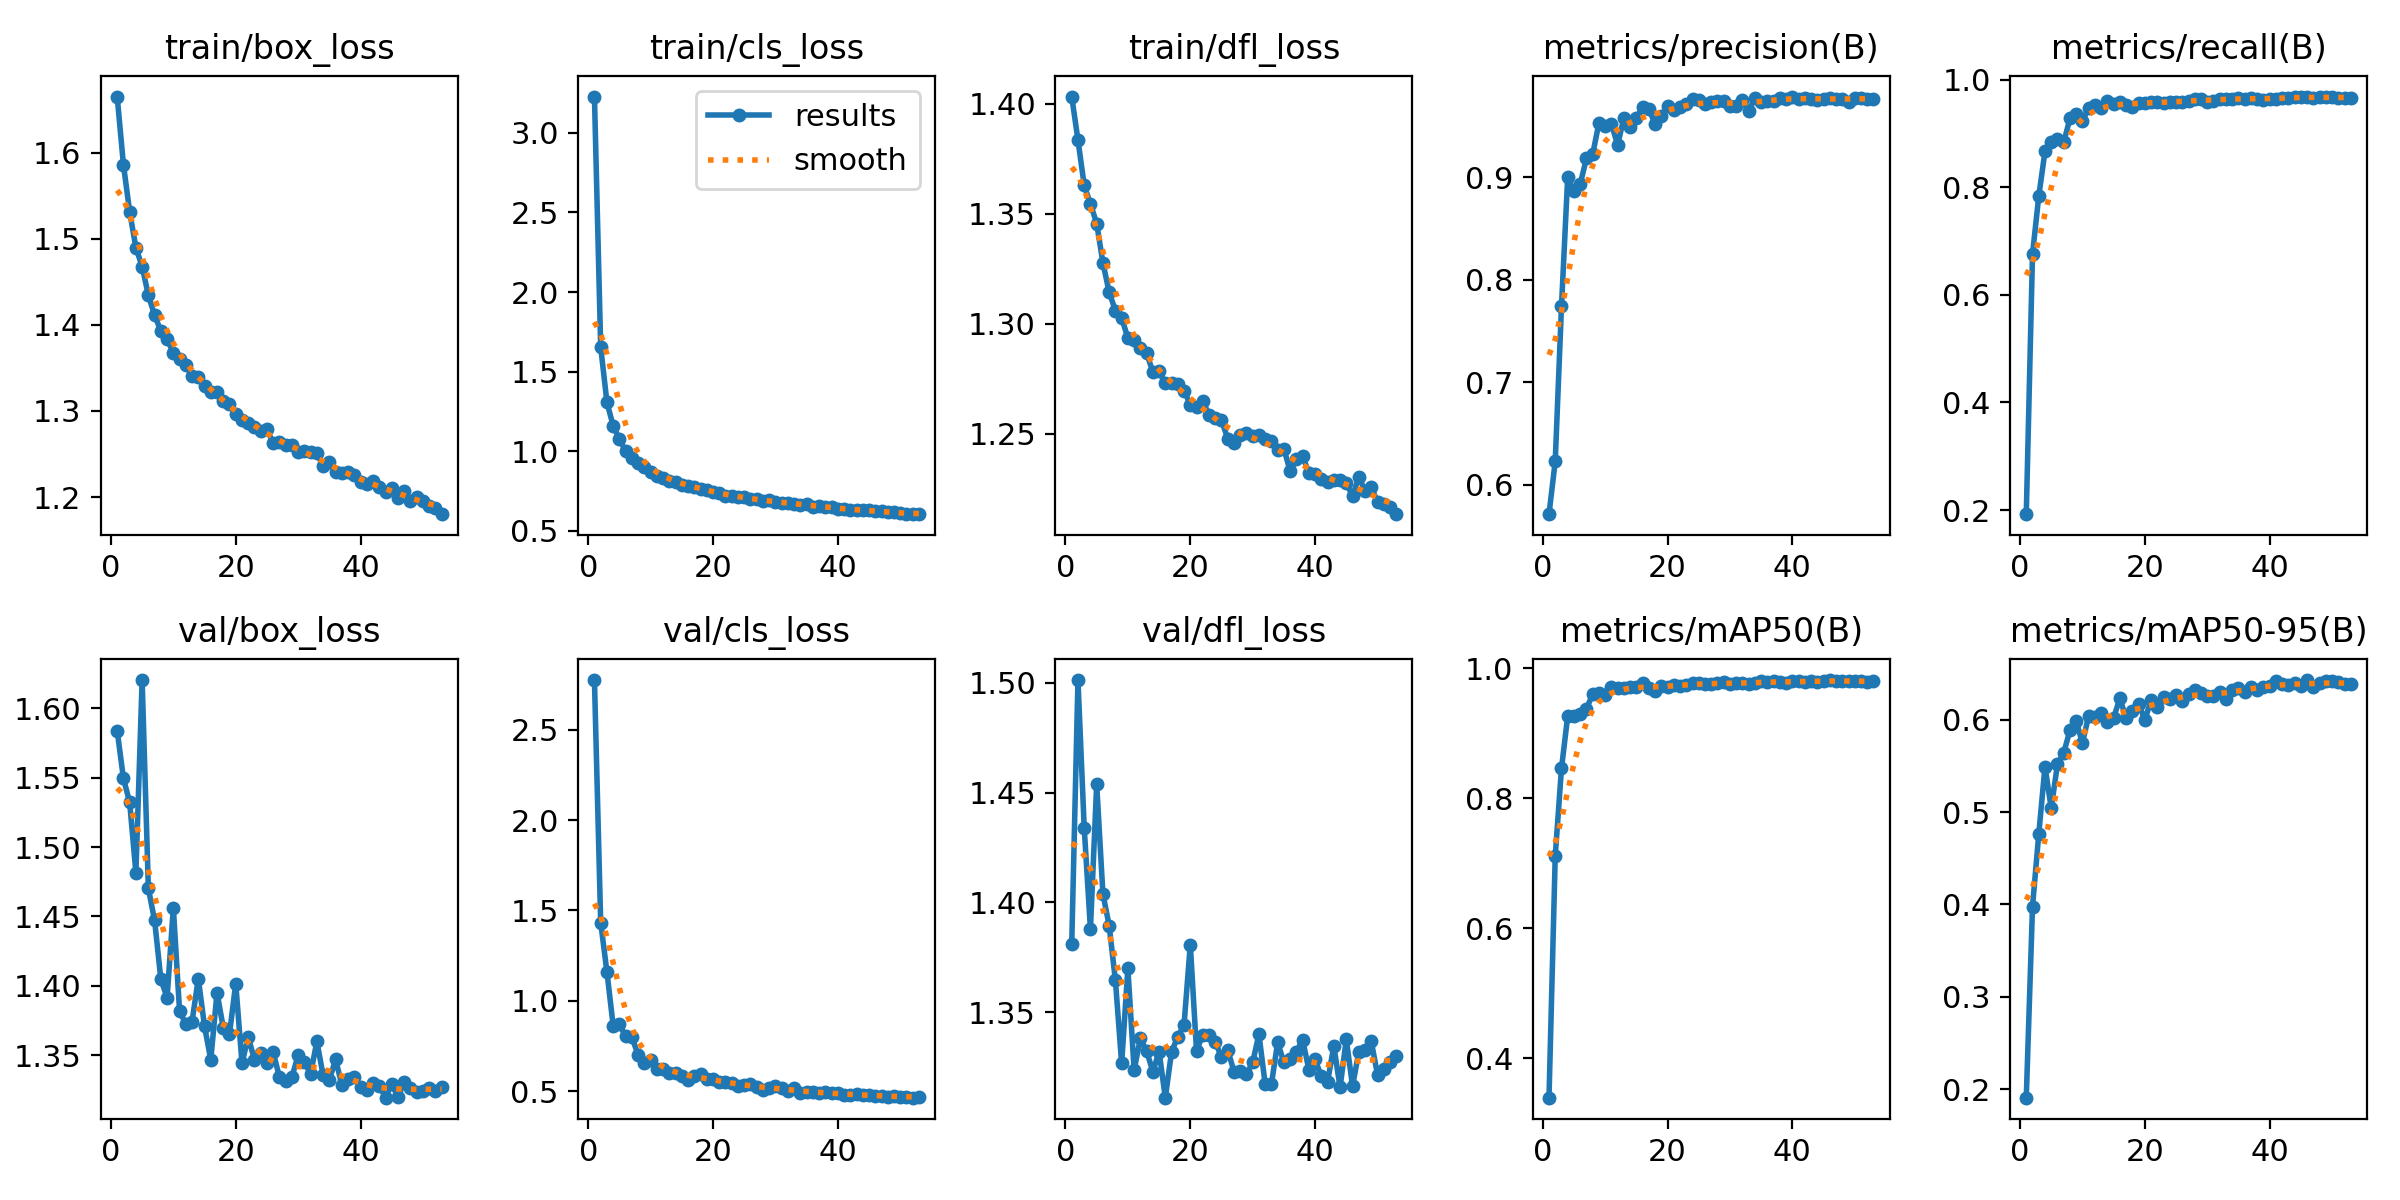

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/results.png', width=900)

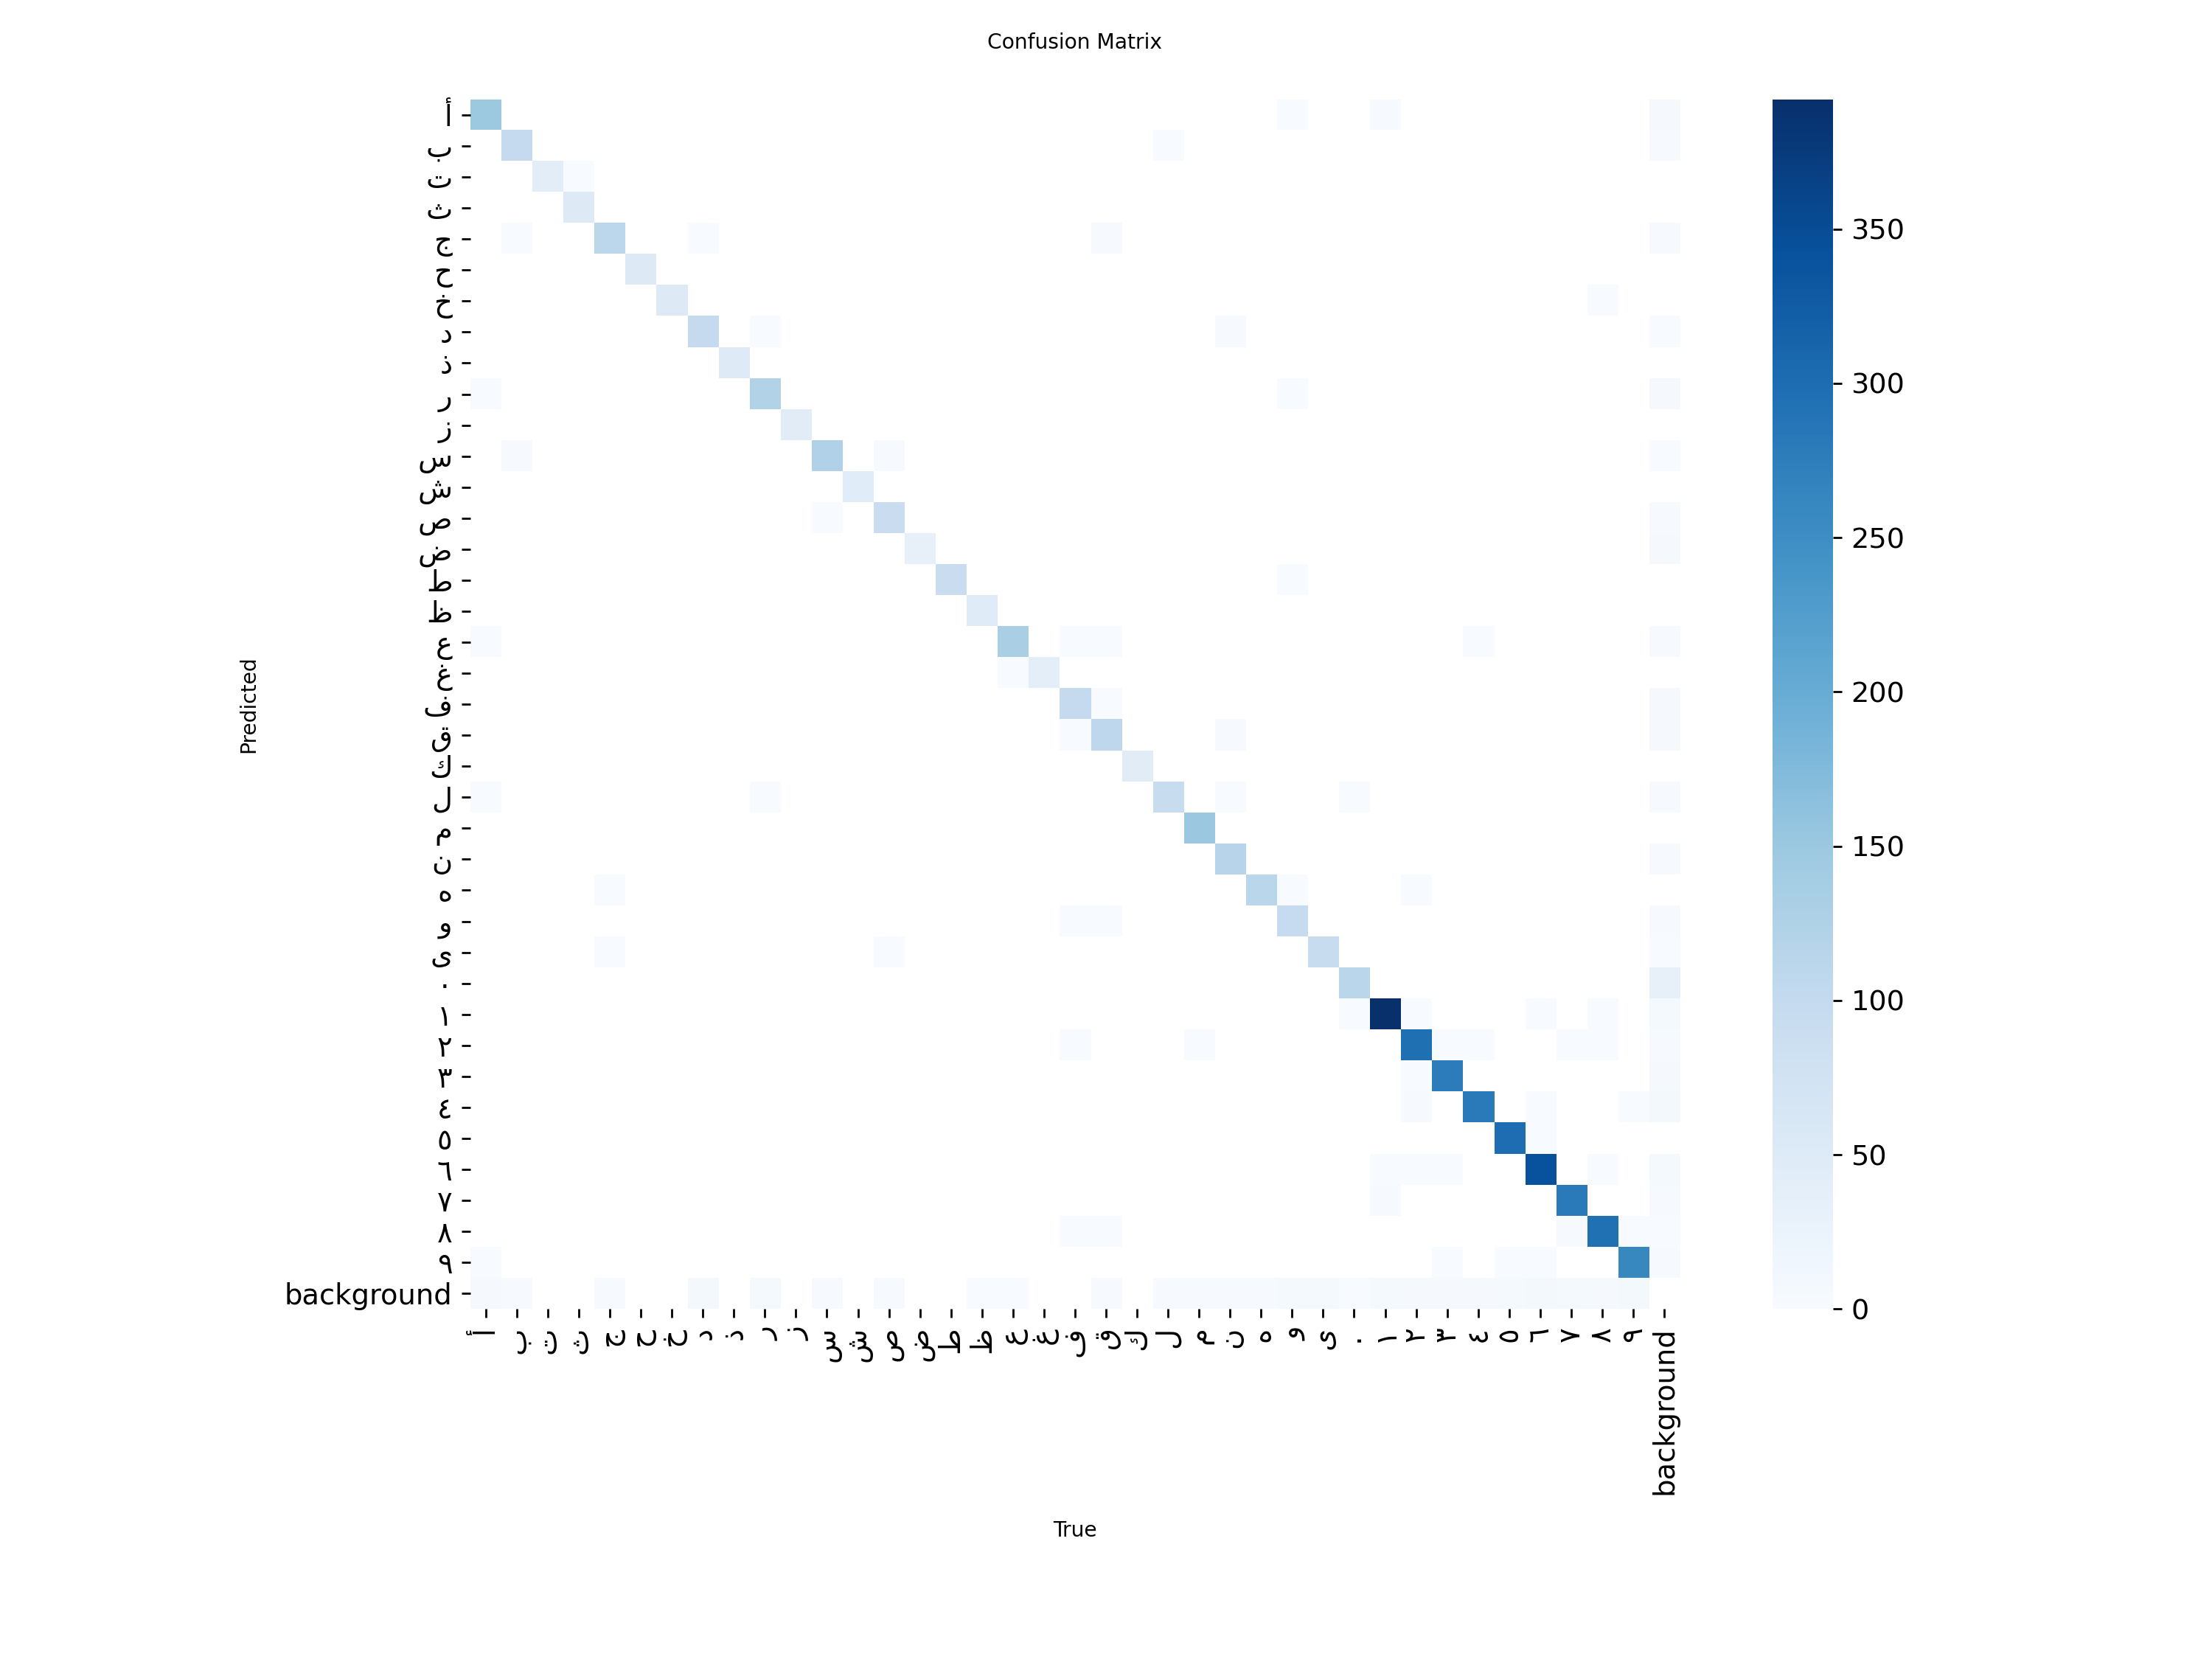

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/confusion_matrix.png', width=900)

## Inference

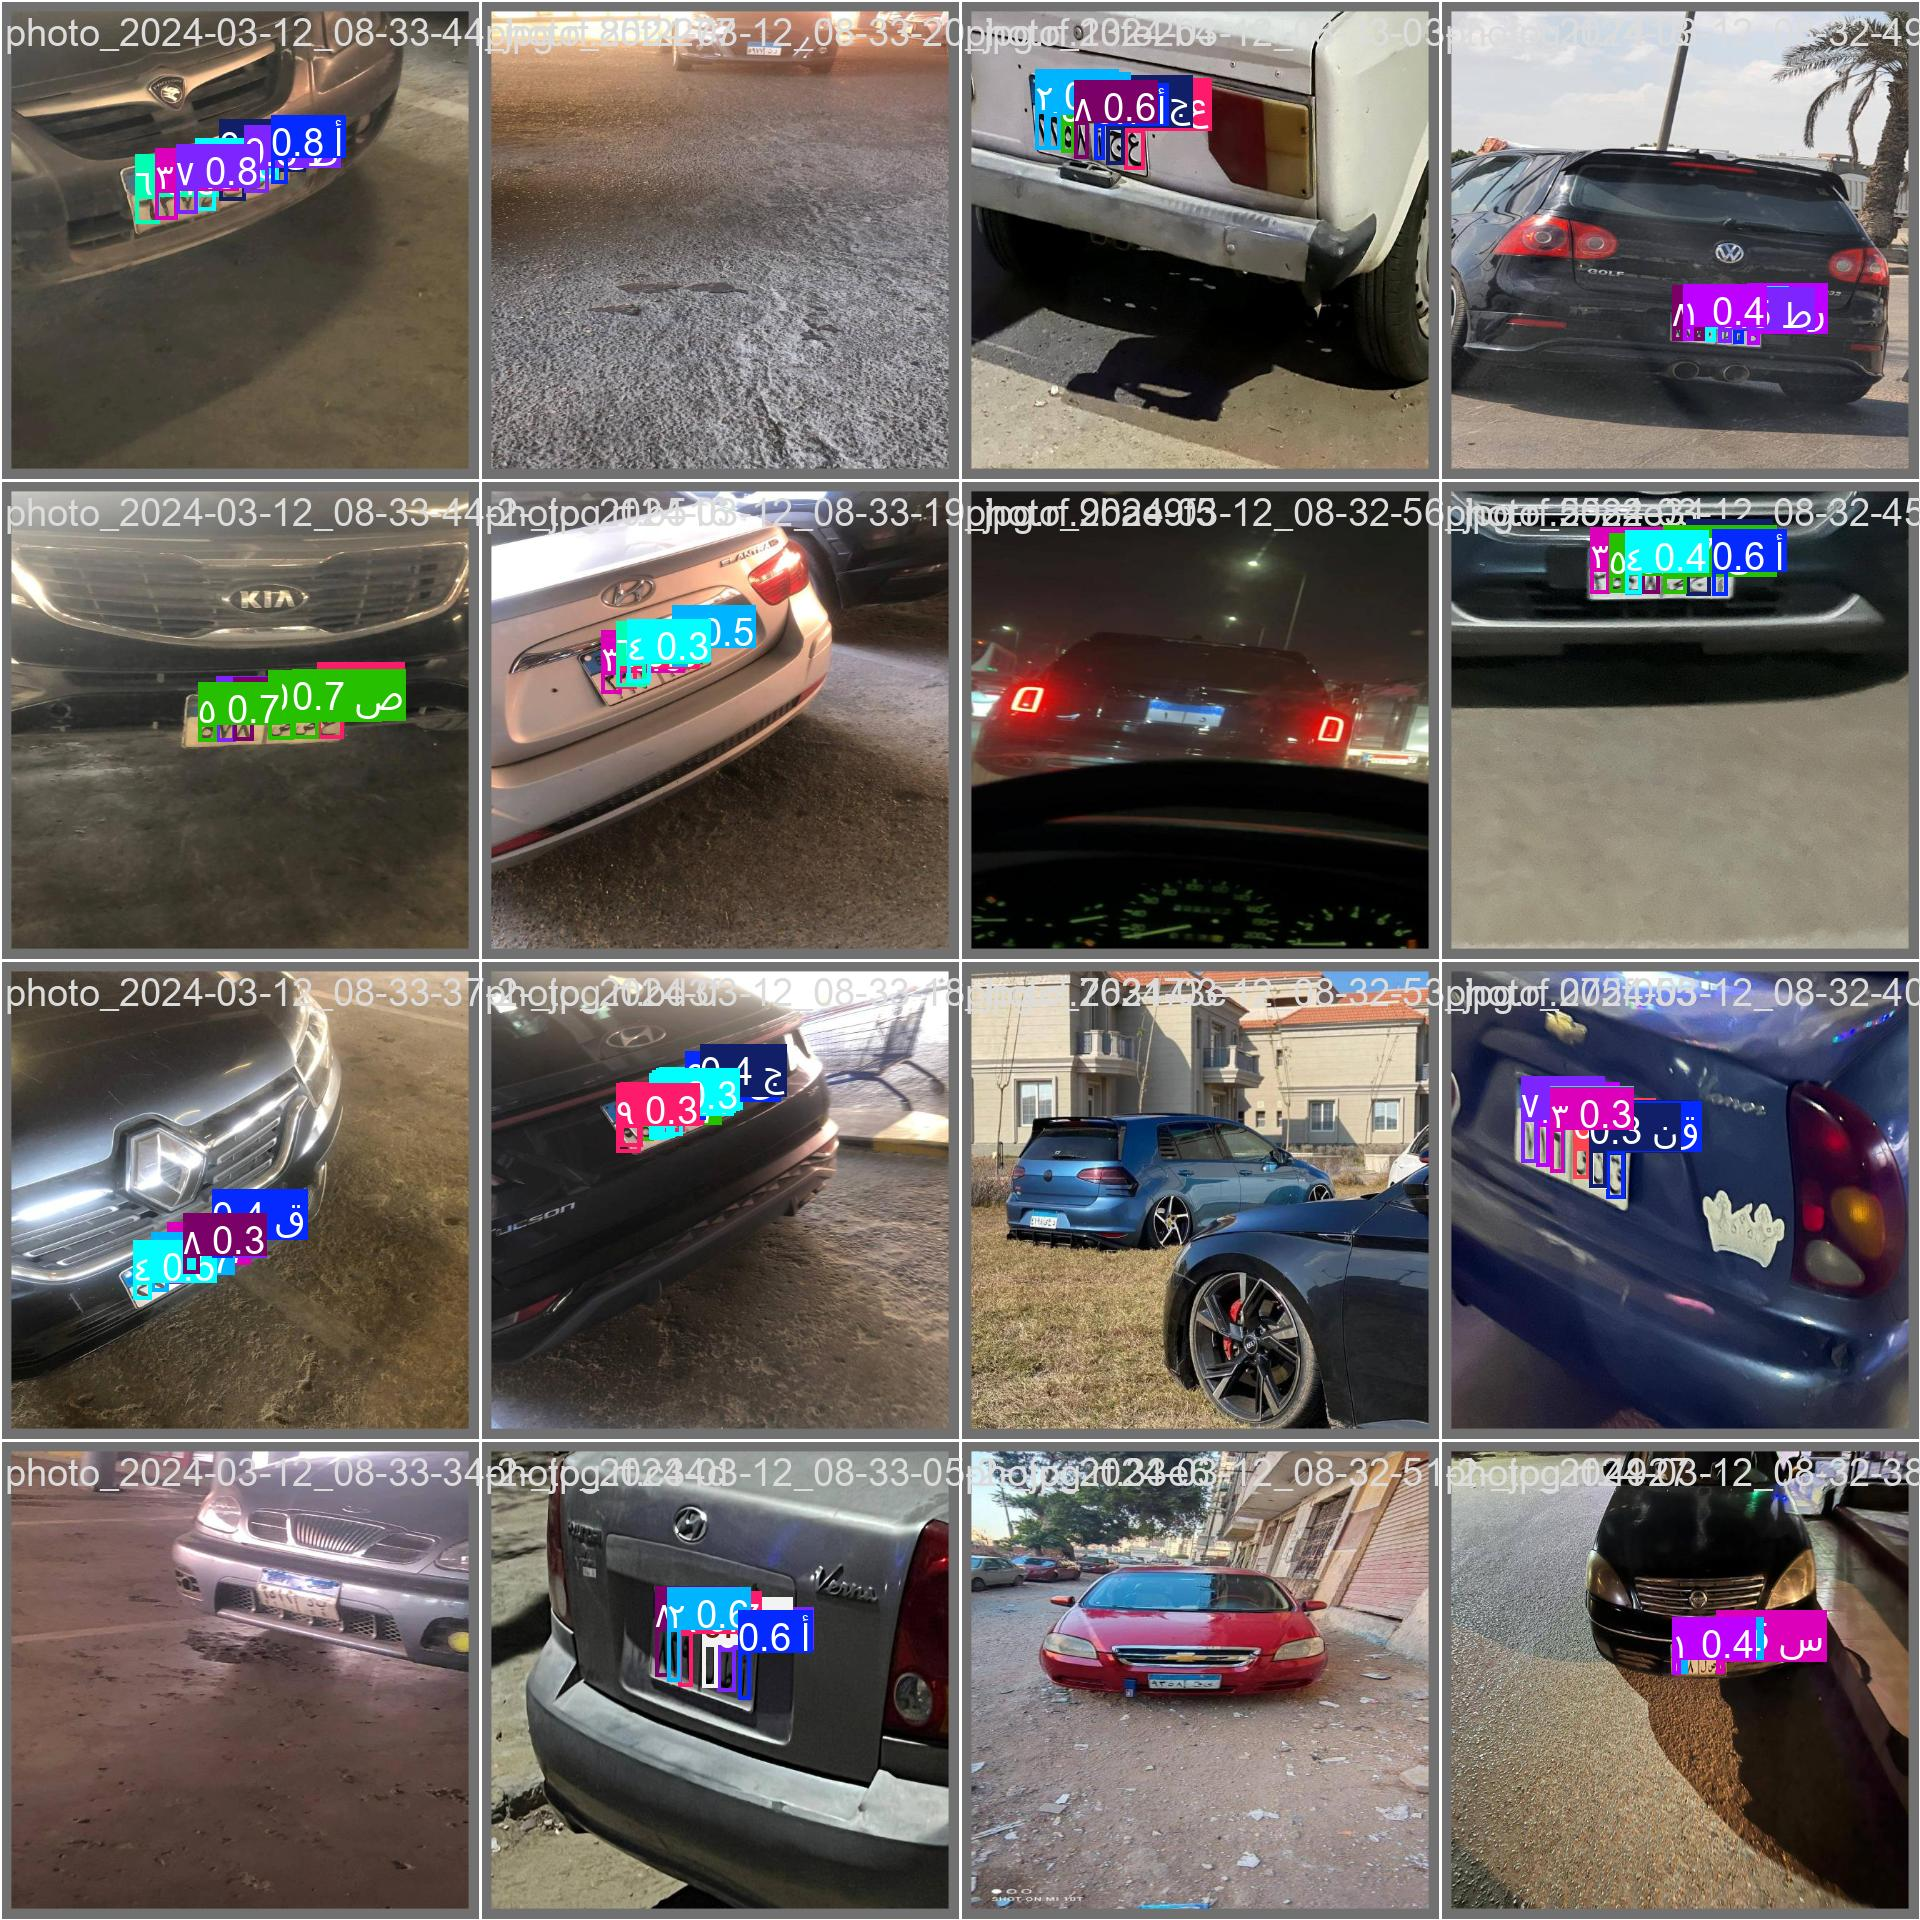

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/val_batch0_pred.jpg', width=1200)

In [ ]:
model.val(data=merged_data_yaml_path, split="test", verbose=True)

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,564,138 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.2±5.0 MB/s, size: 17.7 KB)
val: Scanning /content/merged_car_plates/test/labels... 488 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 488/488 867.3it/s 0.6s
val: New cache created: /content/merged_car_plates/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 5.0it/s 6.1s
                   all        488       2689      0.977      0.969      0.983      0.641
                     أ         82         90      0.976      0.908      0.951      0.482
                     ب         57         60      0.963          1      0.988      0.668
                     ت         20         20       0.98          1      0.995      0.665
                     ث         19         20      0.977          1 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x795fde19c920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,  

In [ ]:
results = model.predict(
    source=f"/content/merged_car_plates/test/images",
    conf=0.5,
    save=True,
    project="runs/detect",
    name="test"
)


image 1/488 /content/merged_car_plates/test/images/00007_jpg.rf.a52c4527d74b058643d04aab31d543e1.jpg: 640x640 1 ذ, 1 س, 1 غ, 1 ١, 1 ٣, 1 ٧, 1 ٩, 15.7ms
image 2/488 /content/merged_car_plates/test/images/00013_jpg.rf.8a8f6ea80b19427e71655452bd6cf095.jpg: 640x640 1 ج, 1 ش, 1 غ, 1 ٥, 11.2ms
image 3/488 /content/merged_car_plates/test/images/00017_jpg.rf.35ba2dc6051de580a57906fbb43295c6.jpg: 640x640 1 ح, 1 ل, 1 ٤, 1 ٥, 1 ٩, 11.5ms
image 4/488 /content/merged_car_plates/test/images/00025_jpg.rf.e09aa4de85297d1bc28304b55688998b.jpg: 640x640 1 ث, 1 ل, 1 ه, 1 ٢, 11.1ms
image 5/488 /content/merged_car_plates/test/images/00032_jpg.rf.d4e18b5f271270a99db028f778c4cba7.jpg: 640x640 1 ح, 1 خ, 1 م, 1 ٩, 11.1ms
image 6/488 /content/merged_car_plates/test/images/00043_jpg.rf.dff901f6faa8fa0076415bdbaab35ce9.jpg: 640x640 1 ش, 1 ل, 1 ٢, 1 ٨, 15.9ms
image 7/488 /content/merged_car_plates/test/images/00047_jpg.rf.b50740ab81ac753885514dd9657825ee.jpg: 640x640 1 ج, 1 س, 1 ض, 1 ٥, 13.4ms
image 8/488 /content

,,,,
,,,,
,,,,
,,,,

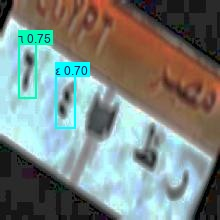
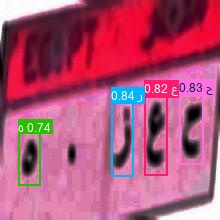
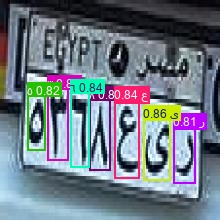
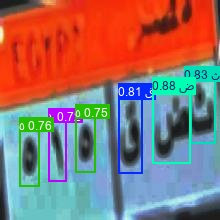
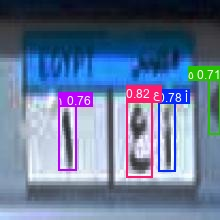
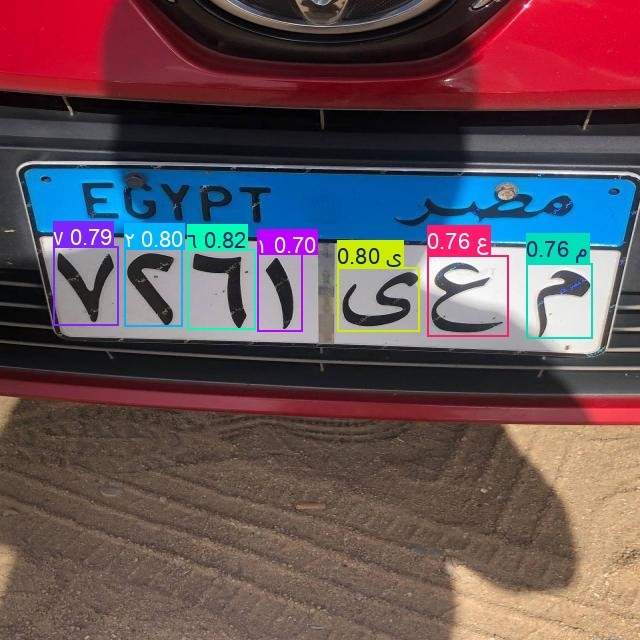
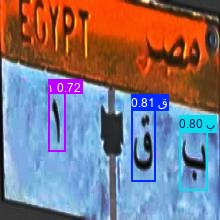
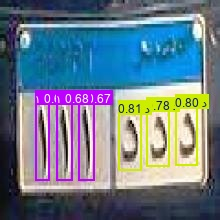
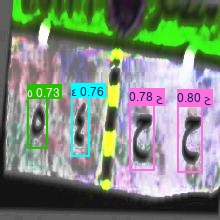
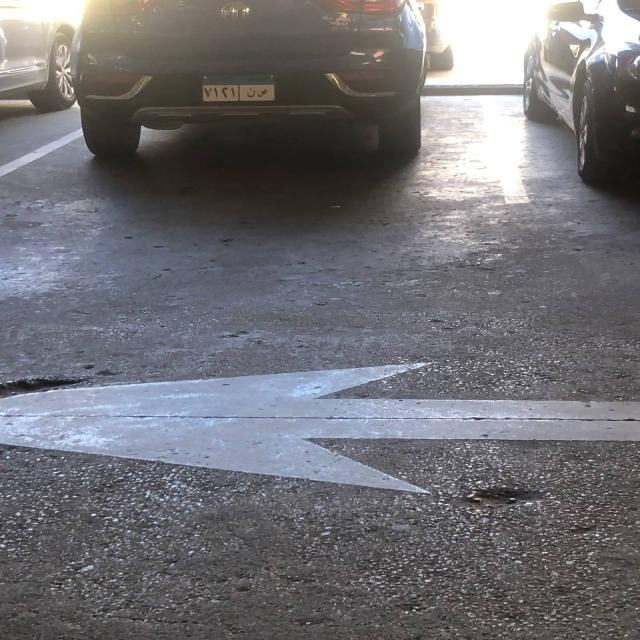
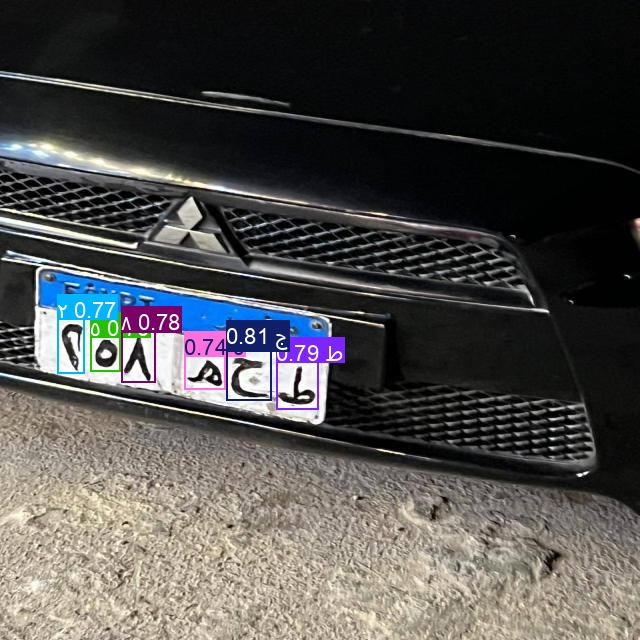
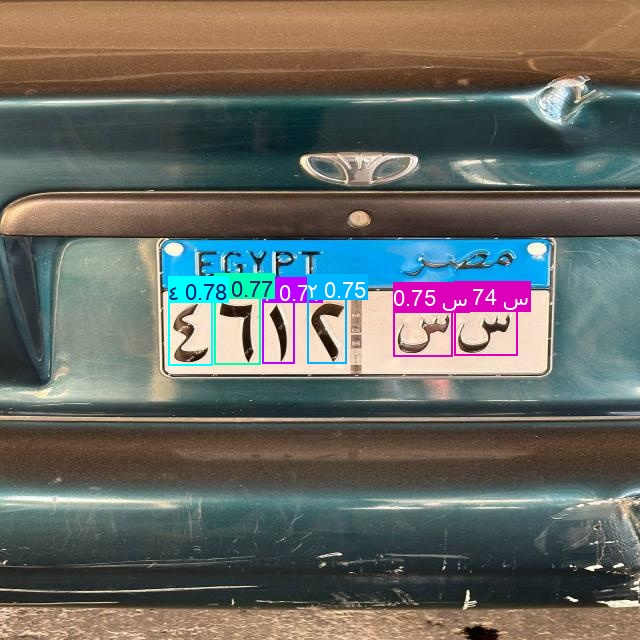
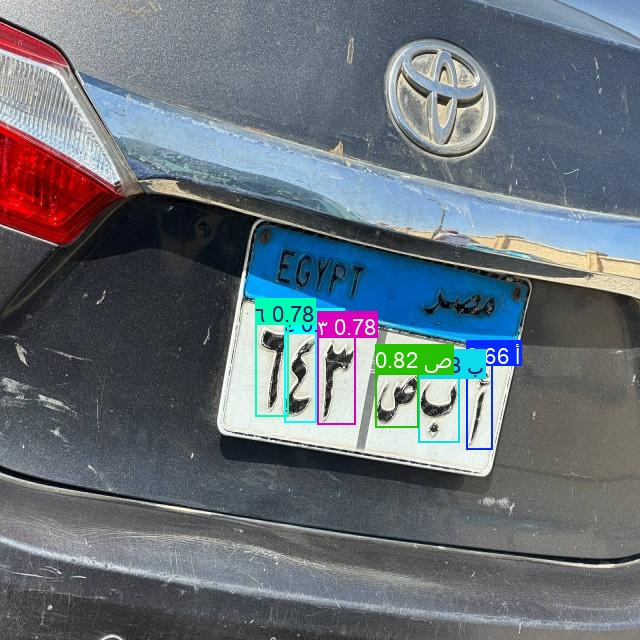
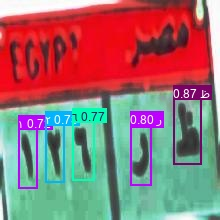
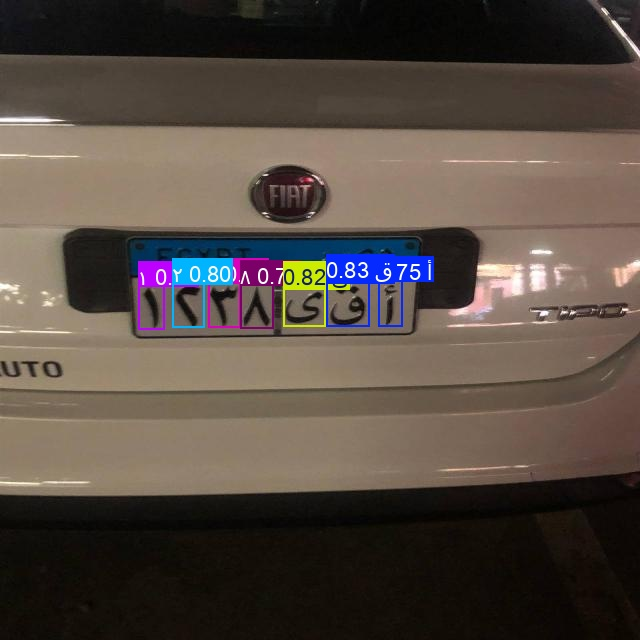
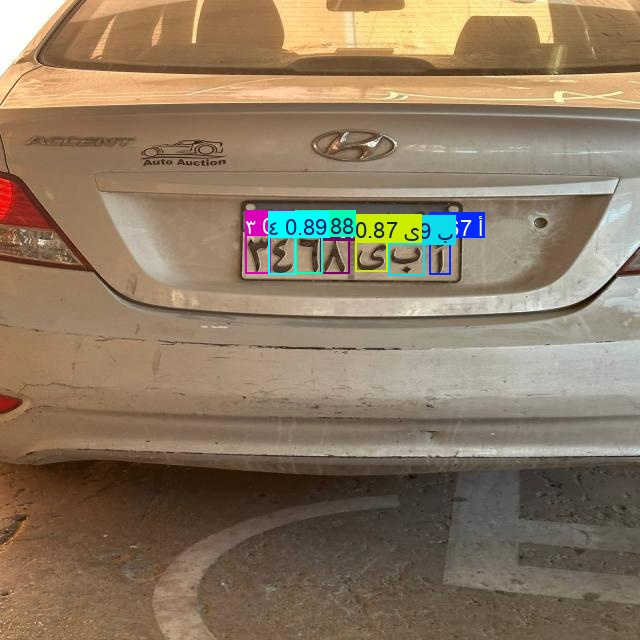
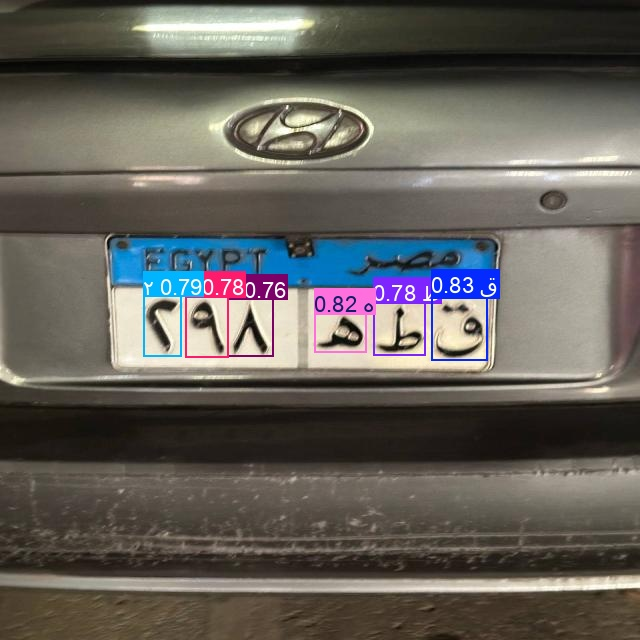
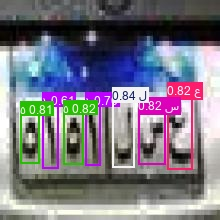
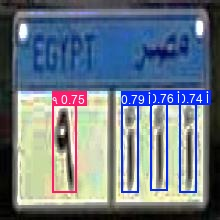
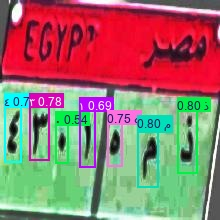

In [ ]:
def img_to_base64(img_path):
    with open(img_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
        return f'<img src="data:image/jpg;base64,{b64}" width="200"/>'

latest_folder = max(glob.glob('/content/runs/detect/test/'), key=os.path.getmtime)
images = glob.glob(f'{latest_folder}/*.jpg')[:20]

imgs_per_row = 5
html = "<table>"
for i in range(0, len(images), imgs_per_row):
    html += "<tr>"
    for img_path in images[i:i+imgs_per_row]:
        html += f"<td>{img_to_base64(img_path)}</td>"
    html += "</tr>"
html += "</table>"

display(HTML(html))